In [20]:
import requests, os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Carga las variables del archivo .env
load_dotenv()
API_KEY = os.getenv("OPENTOPO_API_KEY")

if not API_KEY:
    raise ValueError(
        "No se encontró OPENTOPO_API_KEY en .env."
    )

# Bounding box ZMG con margen de 5km en cada lado
BBOX = {
    "south": 20.30,
    "north": 21.10,
    "west": -104.10,
    "east": -103.00
}

url = (
    f"https://portal.opentopography.org/API/globaldem"
    f"?demtype=SRTMGL1"
    f"&south={BBOX['south']}&north={BBOX['north']}"
    f"&west={BBOX['west']}&east={BBOX['east']}"
    f"&outputFormat=GTiff"
    f"&API_Key={API_KEY}"
)

output_path = "../data/raw/DEM_ZMG_SRTM30m.tif"

print("Descargando DEM...")
response = requests.get(url, stream=True, timeout=120)
response.raise_for_status()

with open(output_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Descarga completa: {os.path.getsize(output_path)/1e6:.1f} MB")

with rasterio.open(output_path) as src:
    print(f"CRS: {src.crs}")
    print(f"Shape: {src.shape}")
    dem_arr = src.read(1).astype(float)
    dem_arr[dem_arr == src.nodata] = np.nan
    print(f"Elev min: {np.nanmin(dem_arr):.0f} m")
    print(f"Elev max: {np.nanmax(dem_arr):.0f} m")

Descargando DEM...
Descarga completa: 12.4 MB
CRS: EPSG:4326
Shape: (2880, 3960)
Elev min: 469 m
Elev max: 2966 m


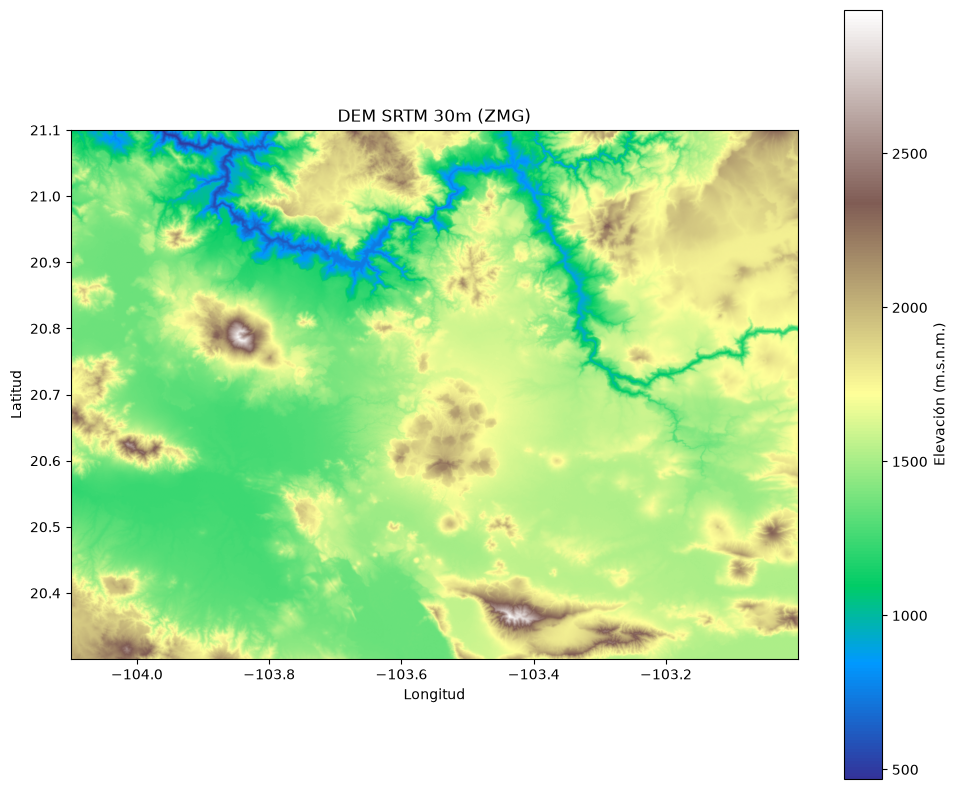

In [21]:
# Visualización del DEM
with rasterio.open(output_path) as src:
    dem_arr = src.read(1).astype(float)
    dem_arr[dem_arr == src.nodata] = np.nan
    extent = [src.bounds.left, src.bounds.right,
              src.bounds.bottom, src.bounds.top]

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(dem_arr, cmap='terrain', extent=extent)
plt.colorbar(img, ax=ax, label='Elevación (m.s.n.m.)')
ax.set_title("DEM SRTM 30m (ZMG)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.savefig("../data/processed/DEM_preview.png", dpi=150)
plt.show()

In [22]:
# Pipeline con pysheds
from pysheds.grid import Grid

grid = Grid.from_raster(output_path)
dem = grid.read_raster(output_path)

print("Paso 1/5: Llenando depresiones...")
pit_filled = grid.fill_pits(dem)

print("Paso 2/5: Rellenando sumideros...")
flooded = grid.fill_depressions(pit_filled)

print("Paso 3/5: Resolviendo zonas planas...")
inflated = grid.resolve_flats(flooded)

print("Paso 4/5: Calculando dirección de flujo...")
fdir = grid.flowdir(inflated)

print("Paso 5/5: Calculando acumulación de flujo...")
acc = grid.accumulation(fdir)

print("\nPipeline completado")
print(f"Acumulación máxima: {np.array(acc).max():,.0f} celdas")

Paso 1/5: Llenando depresiones...
Paso 2/5: Rellenando sumideros...
Paso 3/5: Resolviendo zonas planas...
Paso 4/5: Calculando dirección de flujo...
Paso 5/5: Calculando acumulación de flujo...

Pipeline completado
Acumulación máxima: 6,399,778 celdas


In [23]:
# Cálculo de TWI y pendiente
dem_array = np.array(flooded).astype(float)
acc_array = np.array(acc).astype(float)

# Resolución espacial en metros (SRTM aprox. 30m en latitud aprox. 20°)
res_m = 30.0

# Pendiente en radianes
dy, dx = np.gradient(dem_array, res_m, res_m)
slope = np.arctan(np.sqrt(dx**2 + dy**2))
slope = np.where(slope < 0.001, 0.001, slope)  # evitar división por cero

# Topographic Wetness Index
twi = np.log((acc_array + 1) / np.tan(slope))

print("TWI calculado:")
print(f"Mínimo: {np.nanmin(twi):.2f}")
print(f"Máximo: {np.nanmax(twi):.2f}")
print(f"Mediana: {np.nanmedian(twi):.2f}")

# Guardar TWI como raster
twi_path = "../data/processed/TWI_ZMG.tif"
with rasterio.open(output_path) as src:
    meta = src.meta.copy()
    meta.update(dtype='float32', count=1)
    with rasterio.open(twi_path, 'w', **meta) as dst:
        dst.write(twi.astype('float32'), 1)

print(f"TWI guardado en: {twi_path}")

TWI calculado:
Mínimo: -0.94
Máximo: 22.58
Mediana: 3.75
TWI guardado en: ../data/processed/TWI_ZMG.tif


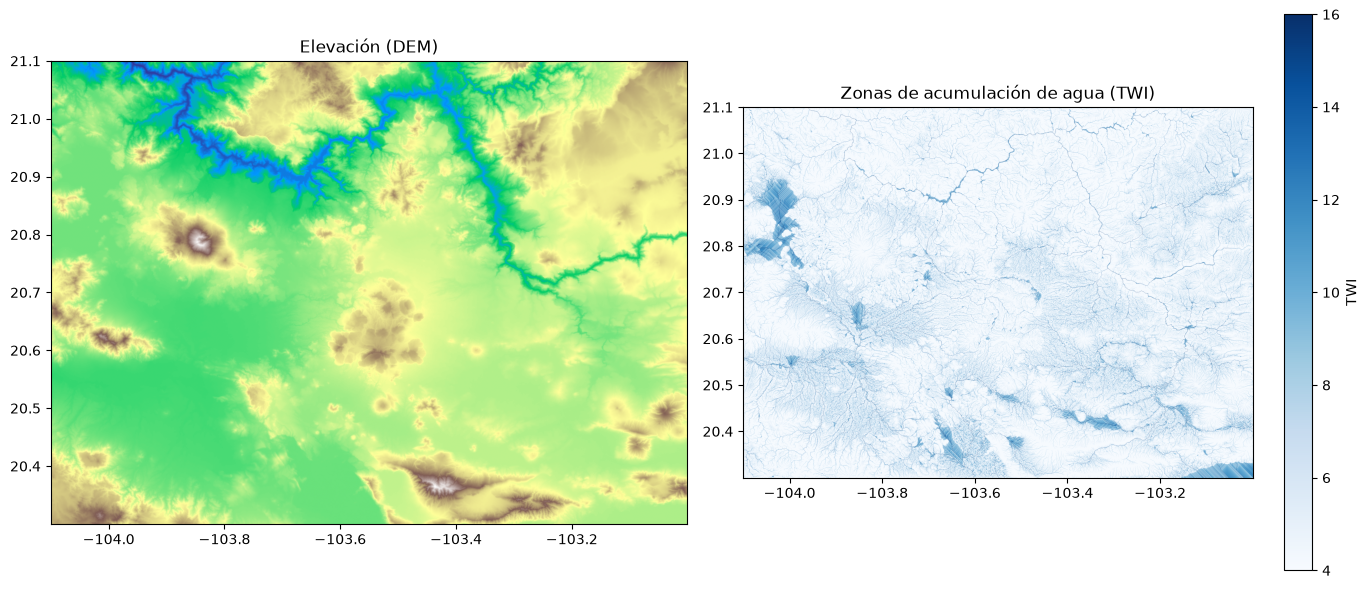

In [25]:
# Visualizar TWI en la ZMG
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(dem_array, cmap='terrain', extent=extent)
axes[0].set_title("Elevación (DEM)")

im = axes[1].imshow(twi, cmap='Blues', extent=extent, vmin=4, vmax=16)
plt.colorbar(im, ax=axes[1], label='TWI')
axes[1].set_title("Zonas de acumulación de agua (TWI)")

plt.tight_layout()
plt.savefig("../data/processed/DEM_TWI_comparativa.png", dpi=150)
plt.show()

In [27]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterstats import zonal_stats
import pandas as pd

gdf_zc = gpd.read_file("../data/processed/ZonasCriticas_limpio.gpkg")

# Reconstruir riesgo_final 
def riesgo_final(row):
    altura = row['altura_cm']
    motivo = row['motivo_norm']
    infra  = row['infra_norm']

    if pd.isna(altura):
        if infra == 'Paso desnivel inferior': return 'Alto'
        elif infra == 'Vivienda': return 'Medio'
        else: return 'Bajo'

    if altura < 50: nivel = 'Bajo'
    elif altura < 100: nivel = 'Medio'
    elif altura < 200: nivel = 'Alto'
    else: nivel = 'Crítico'

    if infra == 'Paso desnivel inferior' and nivel == 'Medio':
        nivel = 'Alto'
    if 'Fuerza de corriente' in str(motivo) and nivel == 'Alto':
        nivel = 'Crítico'
    if 'Aguas negras' in str(motivo):
        nivel = 'Crítico'
    return nivel

gdf_zc['riesgo_final'] = gdf_zc.apply(riesgo_final, axis=1)
print("riesgo_final:")
print(gdf_zc['riesgo_final'].value_counts())

# Leer nodata real de cada raster 
dem_path = "../data/raw/DEM_ZMG_SRTM30m.tif"
twi_path = "../data/processed/TWI_ZMG.tif"
slope_path = "../data/processed/slope_ZMG.tif"

with rasterio.open(dem_path) as src:
    nodata_dem = src.nodata
with rasterio.open(twi_path) as src:
    nodata_twi = src.nodata
with rasterio.open(slope_path) as src:
    nodata_slope = src.nodata

print(f"\nNodata DEM: {nodata_dem}")
print(f"Nodata TWI: {nodata_twi}")
print(f"Nodata slope: {nodata_slope}")

# Polígonos en EPSG:4326 para hacer match con los rasters 
gdf_4326 = gdf_zc.to_crs("EPSG:4326")

# Zonal stats
print("\nExtrayendo features raster por polígono...")

stats_twi = zonal_stats(
    gdf_4326, twi_path,
    stats=["mean", "max", "std"],
    prefix="twi_",
    nodata=nodata_twi
)
stats_slope = zonal_stats(
    gdf_4326, slope_path,
    stats=["mean", "max"],
    prefix="slope_",
    nodata=nodata_slope
)
stats_elev = zonal_stats(
    gdf_4326, dem_path,
    stats=["mean", "min"],
    prefix="elev_",
    nodata=nodata_dem
)

df_twi = pd.DataFrame(stats_twi)
df_slope = pd.DataFrame(stats_slope)
df_elev = pd.DataFrame(stats_elev)

gdf_final = pd.concat(
    [gdf_zc.reset_index(drop=True), df_twi, df_slope, df_elev],
    axis=1
)

# Diagnóstico después de la extracción
feat_cols = ['twi_mean','twi_max','twi_std',
             'slope_mean','slope_max','elev_mean','elev_min']

print("\nEstadísticas (sin -32768):")
print(gdf_final[feat_cols].describe().round(2))
print("\nNulos por columna:")
print(gdf_final[feat_cols].isna().sum())

riesgo_final:
riesgo_final
Medio      60
Bajo       53
Alto       48
Crítico    27
Name: count, dtype: int64

Nodata DEM: -32768.0
Nodata TWI: -32768.0
Nodata slope: -32768.0

Extrayendo features raster por polígono...

Estadísticas (sin -32768):
       twi_mean  twi_max  twi_std  slope_mean  slope_max  elev_mean  elev_min
count    154.00   154.00   154.00      154.00     154.00     154.00    154.00
mean       6.79    10.41     1.96        2.38       4.17    1552.83   1550.99
std        2.59     4.60     1.59        1.71       2.62      42.14     42.32
min        2.70     2.70     0.00        0.00       0.00    1454.00   1454.00
25%        4.81     6.90     0.25        1.50       3.00    1527.30   1525.00
50%        6.34    10.39     1.90        2.00       3.50    1544.00   1541.50
75%        8.12    14.11     3.33        2.91       5.00    1574.75   1573.25
max       15.08    19.96     6.17       17.00      17.00    1683.80   1682.00

Nulos por columna:
twi_mean      34
twi_max       

In [28]:
# Revisar nulos y hacer dataset final
nulos_mask = gdf_final['twi_mean'].isna()
print(f"Polígonos con features nulas: {nulos_mask.sum()}")

if nulos_mask.sum() > 0:
    print("\nDetalle de polígonos problemáticos:")
    print(gdf_final[nulos_mask][
        ['motivo_norm', 'infra_norm', 'altura_cm', 'riesgo_final', 'area_m2']
    ].to_string())

    # Imputar con mediana del mismo nivel de riesgo
    for col in feat_cols:
        for nivel in gdf_final['riesgo_final'].unique():
            mask_nivel = gdf_final['riesgo_final'] == nivel
            mediana    = gdf_final.loc[mask_nivel & ~nulos_mask, col].median()
            gdf_final.loc[mask_nivel & nulos_mask, col] = \
                gdf_final.loc[mask_nivel & nulos_mask, col].fillna(mediana)

    print("\nNulos tras imputación por mediana de clase:")
    print(gdf_final[feat_cols].isna().sum())

Polígonos con features nulas: 34

Detalle de polígonos problemáticos:
             motivo_norm              infra_norm  altura_cm riesgo_final      area_m2
17       Afectación vial  Paso desnivel inferior       40.0         Bajo   498.456896
18       Afectación vial  Paso desnivel inferior       40.0         Bajo   803.484073
29    Ingreso a inmueble            Equipamiento       30.0         Bajo   131.600101
32   Profundidad crítica                Vialidad       70.0        Medio   645.212209
37   Fuerza de corriente                Vialidad      120.0      Crítico   332.265655
43   Profundidad crítica                Vialidad      100.0         Alto   754.200496
45    Ingreso a inmueble                Vivienda       30.0         Bajo   186.763144
47   Fuerza de corriente                Vialidad       60.0        Medio   163.228702
50    Ingreso a inmueble                Vivienda       10.0         Bajo   166.131973
51    Ingreso a inmueble                Vivienda       10.0         Ba

In [29]:
# Dataset final para el modelo
gdf_final['infra_cod']  = pd.Categorical(gdf_final['infra_norm']).codes
gdf_final['motivo_cod'] = pd.Categorical(gdf_final['motivo_norm']).codes

feature_cols = [
    'twi_mean', 'twi_max', 'twi_std',
    'slope_mean', 'slope_max',
    'elev_mean', 'elev_min',
    'altura_cm', 'area_m2',
    'infra_cod', 'motivo_cod'
]

X = gdf_final[feature_cols].fillna(gdf_final[feature_cols].median())
y = gdf_final['riesgo_final']

print("-- Dataset listo para el modelo --")
print(f"Shape : {X.shape}")
print(f"\nFeatures:")
for col in X.columns:
    print(f"{col}  [{X[col].min():.2f} – {X[col].max():.2f}]")
print(f"\nTarget:")
print(y.value_counts())

# Guardar dataset completo con riesgo_final incluido
gdf_final.to_file("../data/processed/dataset_modelo.gpkg", driver="GPKG")
print("\nDataset guardado con columna riesgo_final")

-- Dataset listo para el modelo --
Shape : (188, 11)

Features:
twi_mean  [2.70 – 15.08]
twi_max  [2.70 – 19.96]
twi_std  [0.00 – 6.17]
slope_mean  [0.00 – 17.00]
slope_max  [0.00 – 17.00]
elev_mean  [1454.00 – 1683.80]
elev_min  [1454.00 – 1682.00]
altura_cm  [10.00 – 600.00]
area_m2  [72.51 – 354738.50]
infra_cod  [0.00 – 4.00]
motivo_cod  [0.00 – 4.00]

Target:
riesgo_final
Medio      60
Bajo       53
Alto       48
Crítico    27
Name: count, dtype: int64

Dataset guardado con columna riesgo_final
